# CNN Basics

卷积神经网络用"局部、共享权重"的运算替代全连接。本课从零实现卷积、理解 im2col 的矩阵视角、池化与感受野。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 从全连接到卷积


全连接层把每个输出与**所有**输入相连：$y_j = \sum_i w_{ji}x_i$。图像有 3 个问题：

1. **参数爆炸**：$256\times256\times3$ 输入 → 全连接层就有几十万参数
2. **忽略局部结构**：相邻像素强相关，远处像素无关
3. **不平移不变**：猫在图左还是图右，参数完全不同

**卷积**只用一个小核（如 $3\times3$）滑过图像：**局部连接 + 权重共享**。参数从 $O(WH)$ 降到 $O(k_h k_w)$。


## 2. 卷积运算：互相关


$$(x * w)[i, j] = \sum_{a,b} x[i{+}a,\, j{+}b]\, w[a, b]$$

严格说神经网络用的是**互相关**（不翻转核），习惯上仍叫卷积。步长 stride、填充 padding 控制输出尺寸：

$$H_{out} = \left\lfloor \frac{H + 2\cdot\text{pad} - k_h}{\text{stride}} \right\rfloor + 1$$


In [2]:
def conv2d_manual(x, w, stride=1, pad=0):
    H, W = x.shape; kh, kw = w.shape
    xp = np.pad(x, pad)
    Ho = (H + 2*pad - kh)//stride + 1
    Wo = (W + 2*pad - kw)//stride + 1
    out = np.zeros((Ho, Wo))
    for i in range(Ho):
        for j in range(Wo):
            out[i, j] = np.sum(xp[i*stride:i*stride+kh, j*stride:j*stride+kw] * w)
    return out

# 与 torch 对拍
rng = np.random.default_rng(0)
x = rng.standard_normal((7, 7)); w = rng.standard_normal((3, 3))
out_m = conv2d_manual(x, w, stride=1, pad=1)
out_t = F.conv2d(torch.tensor(x).view(1,1,7,7),
                 torch.tensor(w).view(1,1,3,3), padding=1).squeeze().numpy()
print(f"输出尺寸: {out_m.shape}（7×7 + pad1 - 3 + 1 = 7 ✓）")
print(f"与 torch 最大误差: {np.abs(out_m - out_t).max():.2e}")


输出尺寸: (7, 7)（7×7 + pad1 - 3 + 1 = 7 ✓）
与 torch 最大误差: 8.88e-16


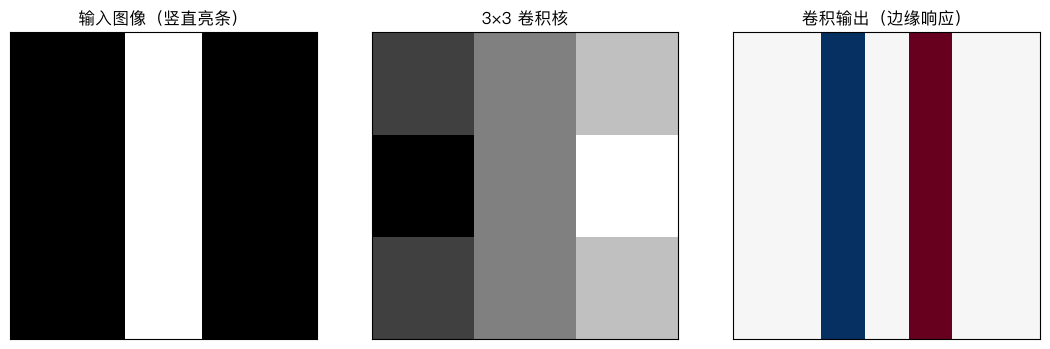

In [3]:
# 边缘检测：一个 3×3 核即可"找到"竖直边缘
img = np.zeros((16, 16))
img[:, 6:10] = 1.0                       # 竖直亮条
k = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])   # Sobel 竖直边缘核

edge = conv2d_manual(img, k)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('输入图像（竖直亮条）')
axes[1].imshow(k, cmap='gray'); axes[1].set_title('3×3 卷积核')
axes[2].imshow(edge, cmap='RdBu'); axes[2].set_title('卷积输出（边缘响应）')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()


## 3. im2col：卷积的矩阵视角


把每个感受野窗口拉成一行（`im2col`），卷积就变成**矩阵乘法** $\text{cols} \times w$——直接复用线性代数与矩阵运算优化：

$$\text{conv}(x, w) = \text{im2col}(x) \cdot w_{\text{flat}}$$


In [4]:
def im2col(x, kh, kw, stride=1, pad=0):
    xp = np.pad(x, pad)
    H, W = xp.shape
    Ho = (H - kh)//stride + 1; Wo = (W - kw)//stride + 1
    cols = np.zeros((Ho*Wo, kh*kw))
    for i in range(Ho):
        for j in range(Wo):
            cols[i*Wo+j] = xp[i*stride:i*stride+kh, j*stride:j*stride+kw].ravel()
    return cols

cols = im2col(x, 3, 3, stride=1, pad=1)
conv_mat = (cols @ w.ravel()).reshape(7, 7)
print(f"im2col 形状: {cols.shape}（49 窗口 × 9 核元素）")
print(f"矩阵乘法卷积 vs 手写卷积 最大误差: {np.abs(conv_mat - out_m).max():.2e}")
print("→ 现代框架（cuDNN 等）正是用 im2col + GEMM 加速卷积")


im2col 形状: (49, 9)（49 窗口 × 9 核元素）
矩阵乘法卷积 vs 手写卷积 最大误差: 8.88e-16
→ 现代框架（cuDNN 等）正是用 im2col + GEMM 加速卷积


## 4. 池化与感受野


**池化**（下采样）：取局部窗口的最大值/平均值，输出尺寸减半。作用：降计算量、提供局部平移不变。

**感受野**：输出像素"看到"的输入区域大小。第 $l$ 层感受野递推（$s_i$ 为到第 $i$ 层的步长累积）：

$$r_l = r_{l-1} + (k_l - 1)\prod_{i<l} s_i$$


In [5]:
def maxpool_manual(x, k=2, stride=2):
    Ho = (x.shape[0] - k)//stride + 1; Wo = (x.shape[1] - k)//stride + 1
    out = np.zeros((Ho, Wo))
    for i in range(Ho):
        for j in range(Wo):
            out[i, j] = x[i*stride:i*stride+k, j*stride:j*stride+k].max()
    return out

print("最大池化 4×4 →", maxpool_manual(rng.standard_normal((4,4))).shape)

# 感受野表：LeNet 风格堆叠
kernels = [5, 2, 5, 2]          # conv5 → pool2 → conv5 → pool2
strides = [1, 2, 1, 2]
r, cum_s = 1, 1
print("\n层 | 核 | 步长 | 感受野")
for i, (k, s) in enumerate(zip(kernels, strides)):
    r = r + (k - 1) * cum_s
    print(f" {i+1} | {k} | {s} | {r}")
    cum_s *= s
print(f"\n最终感受野 = {r}×{r}（conv3 的输出像素在 32×32 输入上看到 14×14，最后再放大到 16×16）")


最大池化 4×4 → (2, 2)

层 | 核 | 步长 | 感受野
 1 | 5 | 1 | 5
 2 | 2 | 2 | 6
 3 | 5 | 1 | 14
 4 | 2 | 2 | 16

最终感受野 = 16×16（conv3 的输出像素在 32×32 输入上看到 14×14，最后再放大到 16×16）


## 5. 现代 CNN 组件


- **1×1 卷积**：在通道维做线性组合（点卷积），改变通道数、加非线性，参数极少
- **padding='same'**：保持分辨率不变（$k$ 奇时 pad $=(k-1)/2$）
- **stride>1 替代池化**：现代网络常用 stride=2 卷积下采样（可学习）
- **深度可分离卷积**：先逐通道、再 1×1 混合 → MobileNet 的核心，参数骤降


## 课后练习


1. **手推尺寸**：$28\times28$ 输入，$5\times5$ 核，pad=2，stride=1 → 输出几乘几？
2. **实现**：给 `conv2d_manual` 加 `stride` 支持并验证输出尺寸公式。
3. **多种边缘核**：试 Sobel 水平核、拉普拉斯核，观察输出差异。
4. **im2col 多通道**：把 im2col 推广到 3 通道输入（cols 形状变成什么？）。
5. **感受野**：VGG 的 $3\times3$ 卷积堆 3 层，感受野是多少？为什么等价一个 $7\times7$ 但参数更少？
